In [ ]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sb
import matplotlib.pyplot as plt

sc.settings.verbosity = 3

%config InlineBackend.format = 'retine'

sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300,
    fontsize=14,
    format='pdf',
    facecolor='none'
)

scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 louvain==0.8.2 pynndescent==0.5.13


In [3]:
adata = sc.read_h5ad('Fibroblast_celltype.h5ad')

In [10]:
list(adata.obs["RawData"].cat.categories)

['C.S.Smillie,et al.Cell.2020',
 'James Kinchen, et al. Cell. 2018',
 'M.Friedrich,et al.Nat Med.2021',
 'Rasa.Elmentaite,et al.Nature.2021']

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


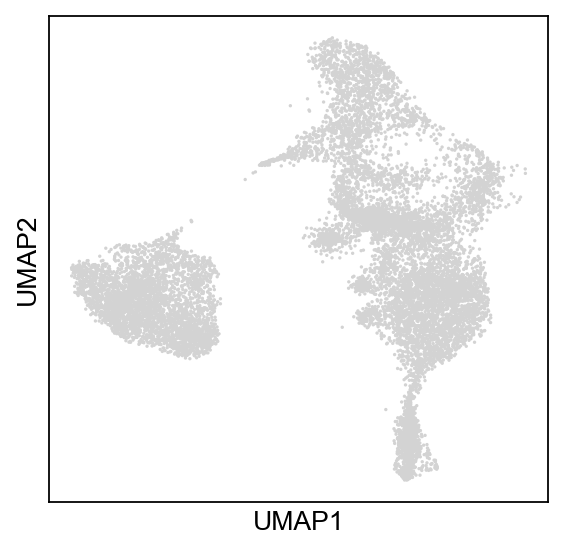

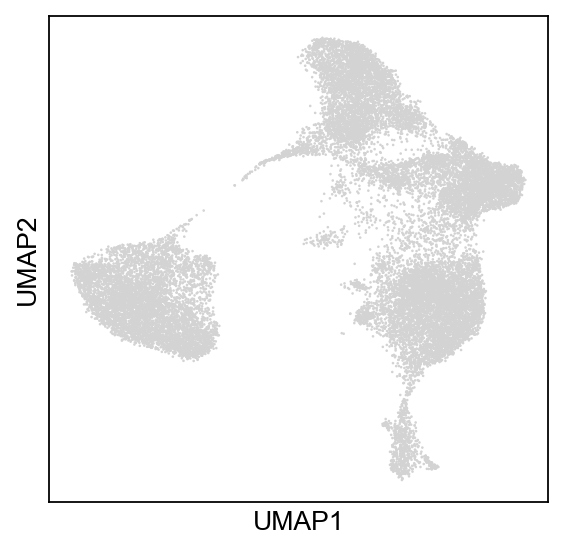

In [4]:
adataUC = adata[adata.obs['class'] == 'UC_inflamed']
adataHealthy = adata[adata.obs['class'] == 'Healthy']
#adataUC_non_inflamed = adata[adata.obs['class'] == 'UC_non_inflamed']
sc.pl.umap(adataUC,)
sc.pl.umap(adataHealthy)
#sc.pl.umap(adataUC_non_inflamed)

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


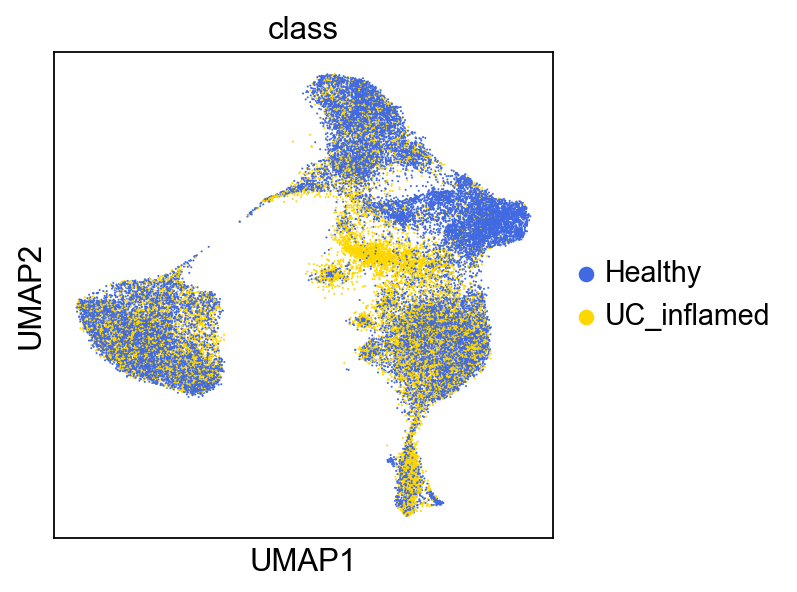

In [60]:
custom_palette = ['royalblue', 'gold'] 
sc.pl.umap(adata, color=['class'],palette=custom_palette,save='Healthy_UC_umap.pdf')

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


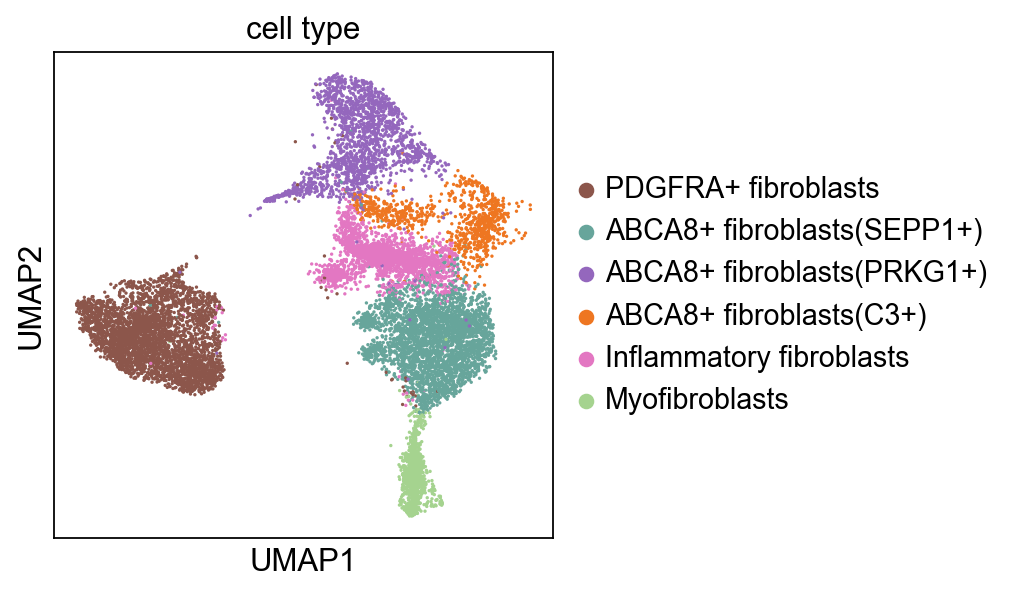

In [53]:
sc.pl.umap(adataUC, color=['cell type'])

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


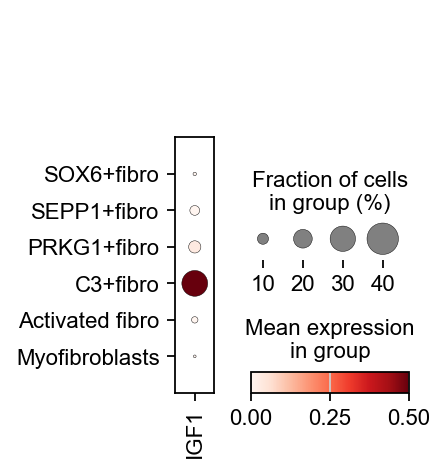

In [14]:
sc.pl.dotplot(adata, ['IGF1'], groupby='cell type', log=False,vmin=0,vmax=0.5,save="IGF1DOT.pdf")

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


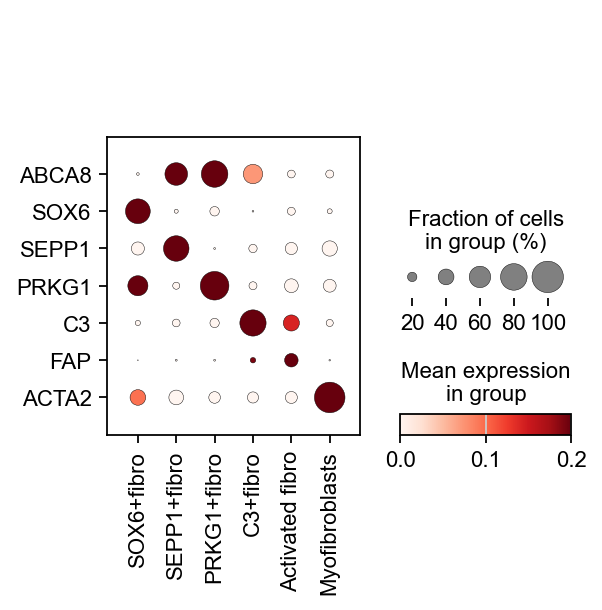

In [37]:
sc.pl.dotplot(adata, ['ABCA8','SOX6','SEPP1','PRKG1','C3','FAP','ACTA2'], 
              groupby='cell type',vmax=0.2,vmin=0,swap_axes=True,log=False,save="celltype_dotplot.pdf")

C:\Users\wangqiang\AppData\Local\Temp\ipykernel_22352\1668759268.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


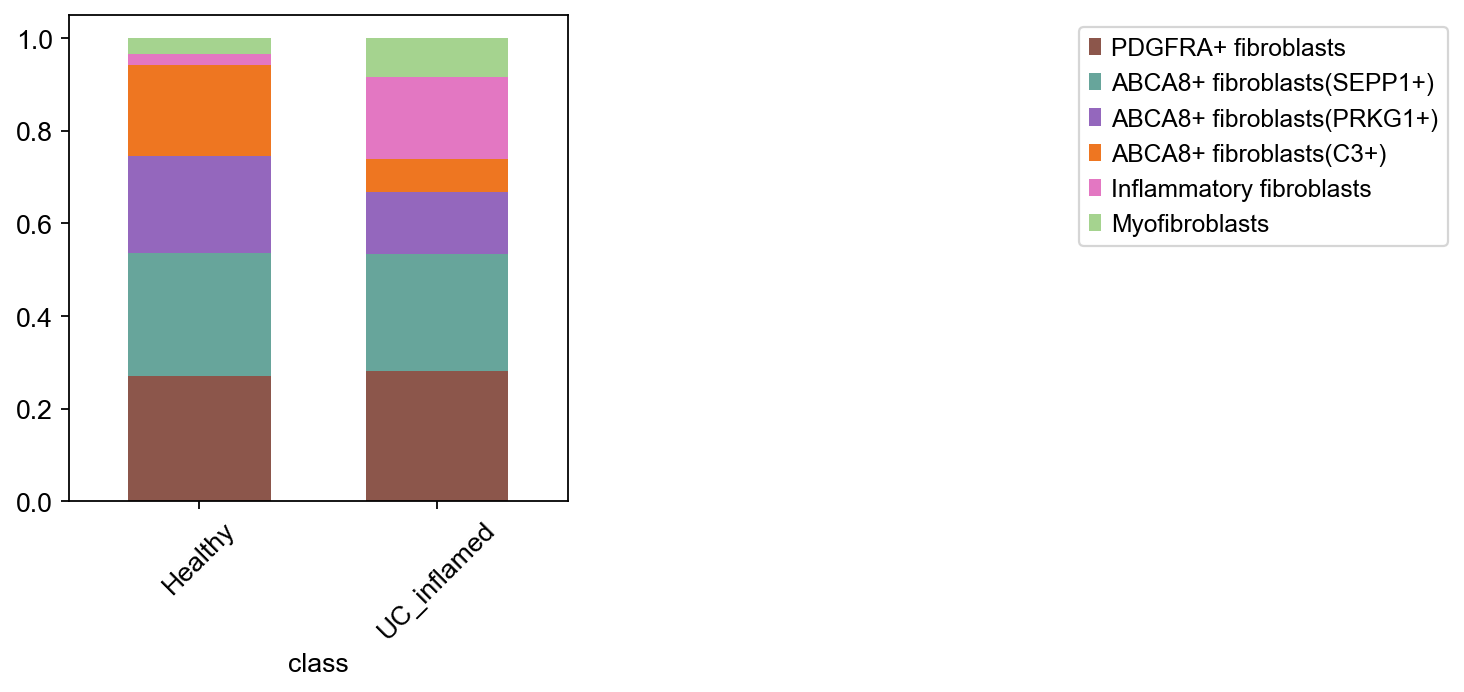

In [ ]:

order = [ 'PDGFRA+ fibroblasts','ABCA8+ fibroblasts(SEPP1+)',
          'ABCA8+ fibroblasts(PRKG1+)','ABCA8+ fibroblasts(C3+)','Inflammatory fibroblasts',
         'Myofibroblasts'] 
adata.obs['cell type'] = pd.Categorical(adata.obs['cell type'], categories=order, ordered=True)
colors = ['#8c564b','#67A59B',  '#9467bd','#EE7621',  '#e377c2', '#A5D38F',]
tmp = pd.crosstab(adata.obs['class'], adata.obs['cell type'],normalize='index')
ax = tmp.plot.bar(stacked=True, width=0.6,color=colors, edgecolor='none') 

ax.legend(loc='upper left', bbox_to_anchor=(2, 1))

ax.grid(False) 

plt.tight_layout()
plt.xticks(rotation=45)

plt.savefig('crosstab.pdf')

plt.show()